In [1]:
import pyflubl
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak

initializing ocelot...


In [20]:
o = pyflubl.Analysis.PyflublOutput(jsonFileName="./pyflubl.json",
                                   jsonCoordinateFileName="./IPAC_2026_coordinate.json",
                                   rootFileName="./IPAC_2026001_pyflubl.root",
                                   dumpFileName="./IPAC_2026001_dump",
                                   usrbinFileName="./IPAC_2026001_fort.24")

FileNotFoundError: [Errno 2] No such file or directory: './IPAC_2026001_dump'

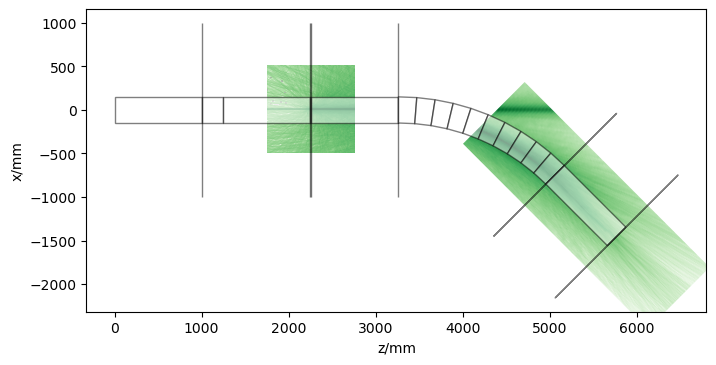

In [3]:
o.plot_projection(eventNumber=-1, detector=1)
plt.savefig("IPAC_2026_usrbin.pdf")

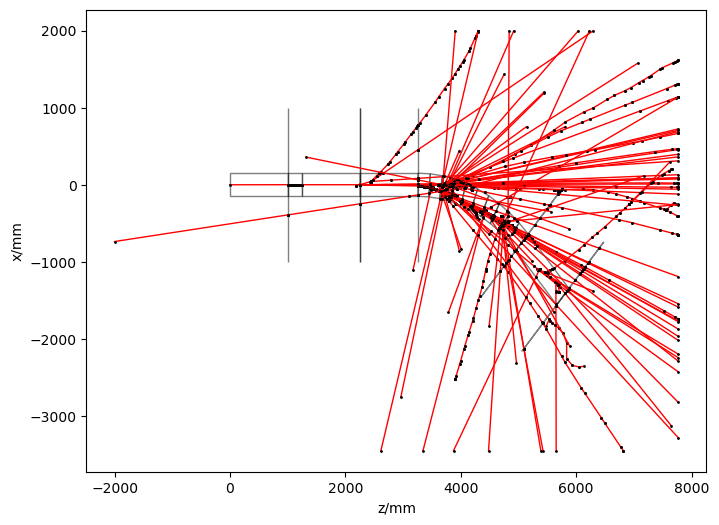

In [17]:
o.plot_projection(eventNumber=4,detector=None)
plt.savefig("IPAC_2026_dump.pdf")

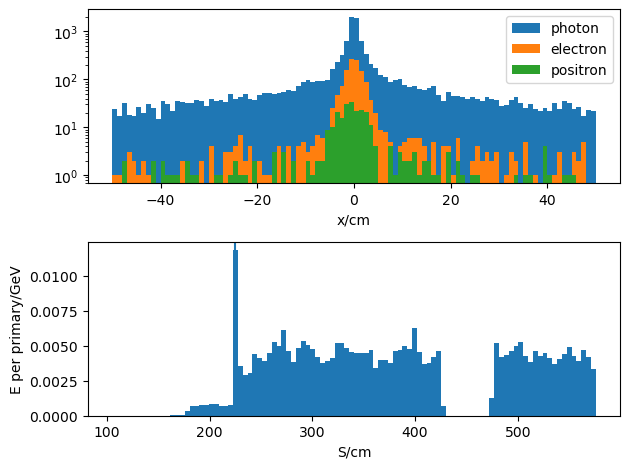

In [14]:
plt.subplot(2,1,1)
s4x = np.array(ak.flatten(o.uprootTree['s4.x'].array(library="ak")))
s4pid = np.array(ak.flatten(o.uprootTree['s4.partID'].array(library="ak")))
plt.hist(s4x[s4pid==7.0],100, (-50,50), label="photon");
plt.hist(s4x[s4pid==3.0],100, (-50,50), label="electron");
plt.hist(s4x[s4pid==4.0],100,  (-50,50), label="positron");
plt.yscale("log")
plt.xlabel("x/cm")
plt.legend();

plt.subplot(2,1,2)
Eloss_E = np.array(ak.flatten(o.uprootTree['eloss.E'].array(library="ak")))/1000
Eloss_S = np.array(ak.flatten(o.uprootTree['eloss.S'].array(library="ak")))
plt.hist(Eloss_S, 100, weights=Eloss_E)
plt.xlabel("S/cm")
plt.ylabel("E per primary/GeV")

plt.axvline(225,ls="--")

plt.tight_layout()
plt.savefig("IPAC_2026_root.pdf")

In [6]:
import pybdsim

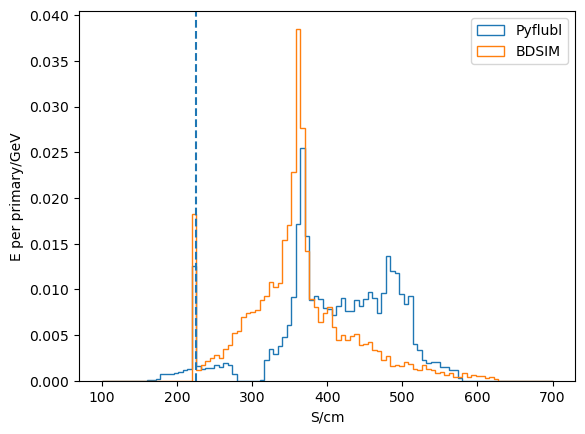

In [22]:
d = pybdsim.DataPandas.Load("./IPAC_2026.root")
el = d.get_eloss()

Eloss_E = np.array(ak.flatten(o.uprootTree['eloss.E'].array(library="ak")))/1000
Eloss_S = np.array(ak.flatten(o.uprootTree['eloss.S'].array(library="ak")))
plt.hist(Eloss_S, 100, (100,700), weights=Eloss_E, histtype="step", label="Pyflubl")

plt.hist(el['S']*100, 100,(100,700), weights=el['energy']/1000, histtype="step", label="BDSIM");

plt.axvline(225,ls="--")

plt.xlabel("S/cm")
plt.ylabel("E per primary/GeV")
plt.legend()

plt.savefig("IPAC_2026_comparision.pdf")